# 04. Seasonal ARIMA and exogenous variables

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahleksu/arima-workshop-ccis/blob/main/notebooks/04_sarima_exogenous.ipynb)

**Module 4.** You will extend ARIMA to repeating patterns (SARIMA), pick seasonal orders with a grid search, add outside drivers with SARIMAX, avoid multicollinearity, and try automated selection with `pmdarima`.

The seasonal ARIMA model is written ARIMA($p$, $d$, $q$)($P$, $D$, $Q$)$_s$:

$$
\phi(B)\,\Phi(B^s)\,(1-B)^d (1-B^s)^D\, y_t = c + \theta(B)\,\Theta(B^s)\,\varepsilon_t.
$$

Capital letters are the seasonal orders. The number $s$ is the season length. Daily data with a weekly pattern has $s = 7$.

In [1]:
# Setup. Runs on Google Colab and on a local install.
import importlib.util, subprocess, sys, warnings
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB and importlib.util.find_spec("statsmodels") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.grid": True, "grid.alpha": 0.3})
RAW = "https://raw.githubusercontent.com/ahleksu/arima-workshop-ccis/main/data/"


def _read_energy(path):
    df = pd.read_csv(path, parse_dates=["date"], index_col="date")
    df.index.freq = "D"
    return df


def load_energy():
    """Load the daily energy demand file. Local copy first, then GitHub, then an upload on Colab."""
    name = "energy_demand_daily.csv"
    for base in (Path("../data"), Path("data"), Path(".")):
        if (base / name).exists():
            return _read_energy(base / name)
    try:
        return _read_energy(RAW + name)
    except Exception as exc:
        if not IN_COLAB:
            raise
        print(f"The download failed ({type(exc).__name__}). Choose {name} from your computer or from Drive.")
        from google.colab import files
        files.upload()
        return _read_energy(Path(name))

In [2]:
from statsmodels.tsa.stattools import adfuller


def adf(series, label, regression="c"):
    """Run the Augmented Dickey-Fuller test and print a plain verdict."""
    stat, pvalue, lags, nobs, crit, _ = adfuller(series.dropna(), regression=regression, autolag="AIC")
    verdict = "reject the unit root (looks stationary)" if pvalue < 0.05 else "cannot reject the unit root (looks non-stationary)"
    print(f"{label:<28} ADF = {stat:7.2f}   p = {pvalue:.4f}   lags = {lags:<3} -> {verdict}")

In [3]:
energy = load_energy()
y = energy["demand_gwh"]

# Exogenous drivers. Heating and cooling load rise as the temperature moves away from 18 C.
exog = pd.DataFrame({
    "hdd": np.maximum(18 - energy["temp_c"], 0),     # heating degrees
    "cdd": np.maximum(energy["temp_c"] - 18, 0),     # cooling degrees
    "holiday": energy["holiday"].astype(float),
})
train_slice = slice("2021-01-01", "2024-06-30")
test_slice = slice("2024-07-01", "2024-12-31")
print("training days:", len(y[train_slice]), "| test days:", len(y[test_slice]))

training days: 1277 | test days: 184


## 1. Spot the season

A weekly pattern shows as spikes in the ACF at lags 7, 14, and 21.

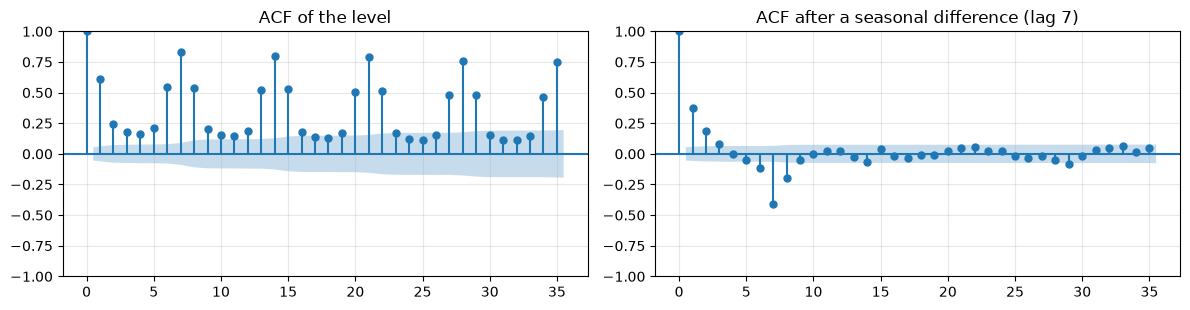

In [4]:
from statsmodels.graphics.tsaplots import plot_acf

train = y[train_slice]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
plot_acf(train, lags=35, ax=axes[0], title="ACF of the level")
plot_acf(train.diff(7).dropna(), lags=35, ax=axes[1], title="ACF after a seasonal difference (lag 7)")
plt.tight_layout()
plt.show()

## 2. Is seasonal differencing needed?

A simple strength measure from the STL decomposition: $F_S = \max(0,\ 1 - \mathrm{Var}(R) / \mathrm{Var}(S + R))$. A value near 1 means a strong season.

In [5]:
from statsmodels.tsa.seasonal import STL

parts = STL(train, period=7, robust=True).fit()
strength = max(0, 1 - parts.resid.var() / (parts.seasonal + parts.resid).var())
print(f"weekly seasonal strength = {strength:.2f}")
adf(train.diff(7), "after seasonal difference")

weekly seasonal strength = 0.78
after seasonal difference    ADF =   -8.60   p = 0.0000   lags = 21  -> reject the unit root (looks stationary)


The weekly pattern is strong, so use $D = 1$ with $s = 7$. Use $D = 1$ at most. Never use $D > 1$ in routine work.

## 3. Seasonal order selection with a grid search

Search a small grid of $(p, q, P, Q)$ with $d = 0$, $D = 1$, $s = 7$. A grid search fits many models, so keep the grid small and state it in your report.

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")      # start-value and convergence notes for some fits
    for p in range(3):
        for q in range(2):
            for P in range(2):
                for Q in range(2):
                    res = SARIMAX(train, order=(p, 0, q), seasonal_order=(P, 1, Q, 7)).fit(disp=False, maxiter=200)
                    rows.append({"p": p, "q": q, "P": P, "Q": Q, "AIC": res.aic, "BIC": res.bic})
grid = pd.DataFrame(rows).sort_values("BIC").reset_index(drop=True)
display(grid.head(5).round(1))
best = grid.iloc[0]
order = (int(best.p), 0, int(best.q))
seasonal_order = (int(best.P), 1, int(best.Q), 7)
print("Chosen by BIC:", order, seasonal_order)

,p,q,P,Q,AIC,BIC
0,2,1,0,1,12267.8,12293.6
1,2,1,1,1,12265.3,12296.2
2,1,1,1,1,12324.8,12350.5
3,1,1,0,1,12331.3,12351.9
4,2,0,1,1,12335.8,12361.5


Chosen by BIC: (2, 0, 1) (0, 1, 1, 7)


## 4. Fit the seasonal model

This is a pure SARIMA model. It uses only the history of the series.

In [7]:
sarima = SARIMAX(train, order=order, seasonal_order=seasonal_order).fit(disp=False, maxiter=200)
print(sarima.summary().tables[1])
print(f"AIC = {sarima.aic:.1f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3414      0.027     49.989      0.000       1.289       1.394
ar.L2         -0.3415      0.020    -17.259      0.000      -0.380      -0.303
ma.L1         -0.8972      0.017    -52.907      0.000      -0.930      -0.864
ma.S.L7       -0.9994      0.162     -6.178      0.000      -1.317      -0.682
sigma2       888.3841    127.884      6.947      0.000     637.736    1139.032
AIC = 12267.8


## 5. Add external drivers with SARIMAX

Demand depends on temperature and holidays. Put them in the model as **exogenous regressors**. The model then becomes a regression with SARIMA errors:

$$
y_t = \beta_1\,\text{hdd}_t + \beta_2\,\text{cdd}_t + \beta_3\,\text{holiday}_t + \eta_t, \qquad \eta_t \sim \text{SARIMA}.
$$

Each $\beta$ has a direct meaning: the change in GWh for one unit of the driver, holding the others fixed.

In [8]:
sarimax = SARIMAX(train, exog=exog[train_slice], order=order, seasonal_order=seasonal_order).fit(disp=False, maxiter=200)
print(sarimax.summary().tables[1])
print(f"\nAIC without drivers = {sarima.aic:.1f}   |   AIC with drivers = {sarimax.aic:.1f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
hdd            6.5125      0.458     14.204      0.000       5.614       7.411
cdd            5.9399      0.483     12.309      0.000       4.994       6.886
holiday     -145.6225      8.637    -16.860      0.000    -162.551    -128.694
ar.L1          1.2966      0.015     87.388      0.000       1.268       1.326
ar.L2         -0.2967      0.015    -20.003      0.000      -0.326      -0.268
ma.L1         -0.9672      0.013    -72.094      0.000      -0.994      -0.941
ma.S.L7       -0.9939      0.035    -28.532      0.000      -1.062      -0.926
sigma2       505.7659     15.374     32.898      0.000     475.634     535.898

AIC without drivers = 12267.8   |   AIC with drivers = 11567.7


**A warning sign in the table.** The seasonal MA coefficient `ma.S.L7` sits near -1. That value means the seasonal difference over-corrected, because the weekly pattern in this data is fixed and does not drift. For a fixed calendar pattern, an alternative is to add weekday dummy variables as exogenous regressors and skip the seasonal difference. Try both on your own data and compare the residual tests.

The data generator used 6.5 GWh per degree for heating and cooling, and -140 GWh for a holiday. The estimates should be close. In real research you never know the truth, so report the standard errors and a sensible range.

## 6. Avoid multicollinearity

If two regressors carry the same information, the coefficients become unstable and the standard errors explode. Temperature (`temp_c`) together with `hdd` and `cdd` is a trap, because `hdd - cdd = 18 - temp_c` exactly. The **variance inflation factor (VIF)** measures this. A common rule is to investigate a VIF above 5 to 10.

In [9]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


def vif_table(df):
    X = sm.add_constant(df)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")           # a singular design gives a harmless warning
        values = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
    return pd.Series(values, index=df.columns, name="VIF")


print("Temperature plus hdd and cdd (perfect collinearity):")
display(vif_table(pd.concat([energy[["temp_c"]], exog[["hdd", "cdd"]]], axis=1)).map(lambda v: f"{v:.3g}").to_frame())
print("hdd, cdd, holiday (fine):")
display(vif_table(exog).round(2).to_frame())

Temperature plus hdd and cdd (perfect collinearity):


,VIF
temp_c,1e+15
hdd,1e+15
cdd,1e+15


hdd, cdd, holiday (fine):


,VIF
hdd,1.66
cdd,1.62
holiday,1.03


**Other ways to protect yourself:** drop one of two related regressors, combine them into an index, or check the correlation matrix before you fit. Also **lag** a regressor only when the lag has a reason, and remember that you need future values of every regressor to forecast.

## 7. What exogenous variables buy you

Forecast the held-out six months with and without the drivers. This test gives the model the **actual** temperature, which is optimistic. In production, you must use a weather forecast, so expect larger errors.

MAE SARIMA (no drivers)   =   23.0 GWh
MAE SARIMAX (with drivers) =   15.2 GWh


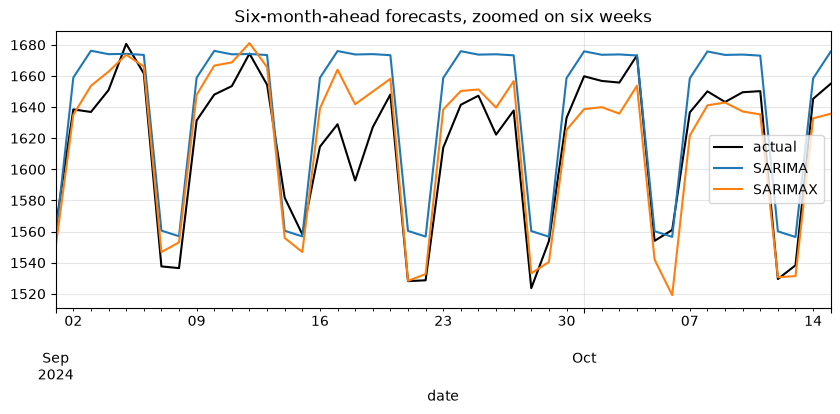

In [10]:
horizon = len(y[test_slice])
f_sarima = sarima.get_forecast(horizon).predicted_mean
f_sarimax = sarimax.get_forecast(horizon, exog=exog[test_slice]).predicted_mean
actual = y[test_slice]

mae = lambda f: (actual - f).abs().mean()
print(f"MAE SARIMA (no drivers)   = {mae(f_sarima):6.1f} GWh")
print(f"MAE SARIMAX (with drivers) = {mae(f_sarimax):6.1f} GWh")

fig, ax = plt.subplots()
actual["2024-09-01":"2024-10-15"].plot(ax=ax, color="black", label="actual")
f_sarima["2024-09-01":"2024-10-15"].plot(ax=ax, label="SARIMA")
f_sarimax["2024-09-01":"2024-10-15"].plot(ax=ax, label="SARIMAX")
ax.legend()
ax.set_title("Six-month-ahead forecasts, zoomed on six weeks")
plt.show()

## 8. Automated selection with `pmdarima`

`auto_arima` runs a stepwise search over the orders. It is a good first pass, not a final answer. You still have to check the residuals. The package is optional, and the cell skips cleanly if it is not installed.

In [11]:
try:
    import pmdarima as pm
except Exception as exc:                       # not installed, or not built for this Python version
    pm = None
    print("pmdarima is not available, skipping this cell:", type(exc).__name__)

if pm is not None:
    window = slice("2023-01-01", "2024-06-30")
    auto = pm.auto_arima(y[window], X=exog[window], seasonal=True, m=7, d=0, D=1,
                         max_p=2, max_q=2, max_P=1, max_Q=1, stepwise=True,
                         suppress_warnings=True, error_action="ignore")
    print("auto_arima picked:", auto.order, auto.seasonal_order)
    print("manual grid picked:", order, seasonal_order)

auto_arima picked: (2, 0, 0) (0, 1, 1, 7)
manual grid picked: (2, 0, 1) (0, 1, 1, 7)


## Take-home

- Seasonal differencing handles a repeating pattern. Use $D \le 1$.
- Exogenous variables can cut the error a lot, but you need their future values.
- Check VIF before you add regressors.
- Use `auto_arima` for a first pass and then diagnose.

**Next:** notebook 05 tests the forecasts honestly with rolling backtests.